In [2]:
# ============================================================
# KAGGLE TFLITE TESTING — SETUP
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parents[1]

TEST_CSV = (
    PROJECT_ROOT
    / "ml"
    / "data"
    / "splits"
    / "kaggle"
    / "test.csv"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "ml"
    / "models"
    / "kaggle"
    / "coconut_health_pest_model.tflite"
)

RESULT_DIR = (
    PROJECT_ROOT
    / "ml"
    / "results"
    / "kaggle"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_SIZE = (224, 224)

CLASS_NAMES = [
    "CCI_Caterpillars",
    "CCI_Leaflets",
    "Healthy_Leaves",
    "WCLWD_DryingofLeaflets",
    "WCLWD_Flaccidity",
    "WCLWD_Yellowing"
]

CLASS_TO_INDEX = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

print("=" * 60)
print("KAGGLE TFLITE TESTING SETUP")
print("=" * 60)

print("Test CSV :", TEST_CSV)
print("Model    :", MODEL_PATH)

print("\nTest CSV exists :", TEST_CSV.exists())
print("Model exists    :", MODEL_PATH.exists())

KAGGLE TFLITE TESTING SETUP
Test CSV : /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/data/splits/kaggle/test.csv
Model    : /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/kaggle/coconut_health_pest_model.tflite

Test CSV exists : True
Model exists    : True


In [3]:
# ============================================================
# LOAD TEST CSV
# ============================================================

test_df = pd.read_csv(TEST_CSV)

print("=" * 60)
print("TEST DATASET")
print("=" * 60)

print("Total test images:", len(test_df))

print("\nColumns:")
print(test_df.columns.tolist())

print("\nClass distribution:")
print(test_df["label"].value_counts().sort_index())

print("\nFirst 5 rows:")
display(test_df.head())

TEST DATASET
Total test images: 771

Columns:
['image_path', 'label']

Class distribution:
label
CCI_Caterpillars          148
CCI_Leaflets              119
Healthy_Leaves             19
WCLWD_DryingofLeaflets    162
WCLWD_Flaccidity          161
WCLWD_Yellowing           162
Name: count, dtype: int64

First 5 rows:


,image_path,label
0,/home/sivabharathi/Documents/FinalYearProject/...,WCLWD_DryingofLeaflets
1,/home/sivabharathi/Documents/FinalYearProject/...,WCLWD_Flaccidity
2,/home/sivabharathi/Documents/FinalYearProject/...,CCI_Caterpillars
3,/home/sivabharathi/Documents/FinalYearProject/...,WCLWD_Flaccidity
4,/home/sivabharathi/Documents/FinalYearProject/...,WCLWD_Flaccidity


In [4]:
# ============================================================
# LOAD TFLITE MODEL
# ============================================================

interpreter = tf.lite.Interpreter(
    model_path=str(MODEL_PATH)
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("=" * 60)
print("TFLITE MODEL")
print("=" * 60)

print("\nInput shape:")
print(input_details[0]["shape"])

print("Input dtype:")
print(input_details[0]["dtype"])

print("\nOutput shape:")
print(output_details[0]["shape"])

print("Output dtype:")
print(output_details[0]["dtype"])

TFLITE MODEL

Input shape:
[  1 224 224   3]
Input dtype:
<class 'numpy.float32'>

Output shape:
[1 6]
Output dtype:
<class 'numpy.float32'>


/home/sivabharathi/miniconda3/envs/mldlenv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [5]:
# ============================================================
# RUN TFLITE ON COMPLETE TEST SET
# ============================================================

y_true = []
y_pred = []
confidences = []

for _, row in test_df.iterrows():

    image_path = row["image_path"]
    actual_label = row["label"]

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize
    image = image.resize(IMAGE_SIZE)

    # Convert to float32
    image_array = np.array(
        image,
        dtype=np.float32
    )

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # Input
    interpreter.set_tensor(
        input_details[0]["index"],
        image_array
    )

    # Inference
    interpreter.invoke()

    # Output
    predictions = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    predicted_index = int(
        np.argmax(predictions)
    )

    confidence = float(
        predictions[predicted_index]
    )

    # Store results
    y_true.append(
        CLASS_TO_INDEX[actual_label]
    )

    y_pred.append(
        predicted_index
    )

    confidences.append(
        confidence
    )

# Convert to NumPy
y_true = np.array(y_true)
y_pred = np.array(y_pred)
confidences = np.array(confidences)

# Accuracy
accuracy = accuracy_score(
    y_true,
    y_pred
)

print("\n" + "=" * 60)
print("KAGGLE TFLITE RESULTS")
print("=" * 60)

print(f"Total images       : {len(y_true)}")
print(f"Correct predictions: {np.sum(y_true == y_pred)}")
print(f"Wrong predictions  : {np.sum(y_true != y_pred)}")
print(f"TFLite Accuracy    : {accuracy:.4%}")
print(f"Average Confidence : {np.mean(confidences):.4%}")


KAGGLE TFLITE RESULTS
Total images       : 771
Correct predictions: 762
Wrong predictions  : 9
TFLite Accuracy    : 98.8327%
Average Confidence : 97.9289%


KAGGLE TFLITE CLASSIFICATION REPORT
                        precision    recall  f1-score   support

      CCI_Caterpillars     1.0000    1.0000    1.0000       148
          CCI_Leaflets     1.0000    1.0000    1.0000       119
        Healthy_Leaves     0.7917    1.0000    0.8837        19
WCLWD_DryingofLeaflets     0.9877    0.9877    0.9877       162
      WCLWD_Flaccidity     1.0000    0.9689    0.9842       161
       WCLWD_Yellowing     0.9877    0.9877    0.9877       162

              accuracy                         0.9883       771
             macro avg     0.9612    0.9907    0.9739       771
          weighted avg     0.9897    0.9883    0.9887       771


TFLITE CONFUSION MATRIX
[[148   0   0   0   0   0]
 [  0 119   0   0   0   0]
 [  0   0  19   0   0   0]
 [  0   0   0 160   0   2]
 [  0   0   5   0 156   0]
 [  0   0   0   2   0 160]]


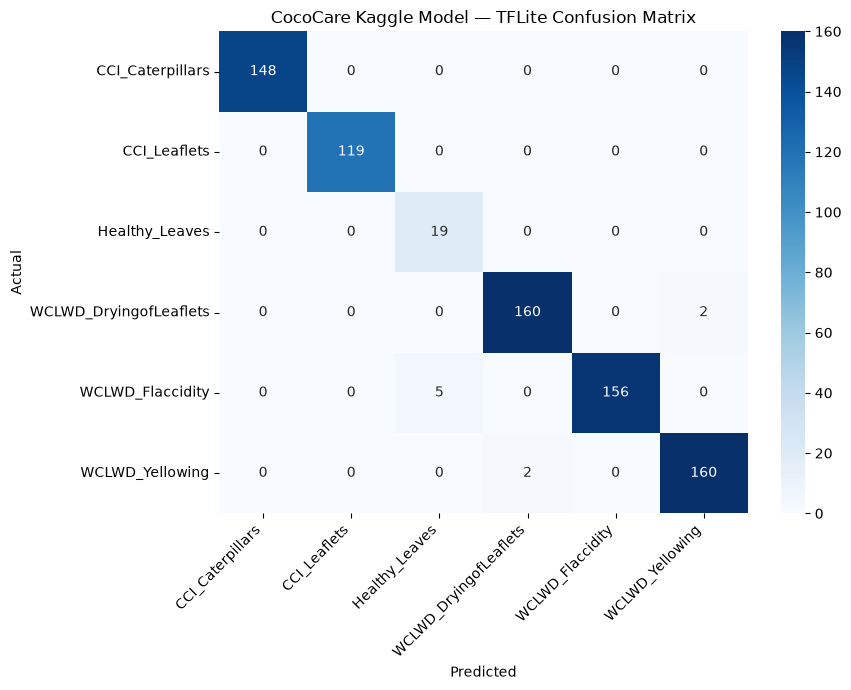


Saved: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/results/kaggle/kaggle_tflite_confusion_matrix.png


In [6]:
# ============================================================
# TFLITE CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("KAGGLE TFLITE CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n" + "=" * 60)
print("TFLITE CONFUSION MATRIX")
print("=" * 60)

print(cm)

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CocoCare Kaggle Model — TFLite Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

cm_path = RESULT_DIR / "kaggle_tflite_confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:", cm_path)